## Analysis of Students Data .


In [46]:
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

raw_data_path =Path('../data/raw/StudentPerformanceFactors.csv')
output_data_path=Path('../data/processed/StudentPerformanceFactor.csv')




In [47]:
data=pd.read_csv(raw_data_path)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [48]:
data.head()
# data.tail()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [49]:
data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### what's the max/min Marks obtained ?

In [50]:
print(data['Exam_Score'].max())
print(data['Exam_Score'].min())


101
55


In [51]:
# dropping the marks above 100
data.drop(data[data['Previous_Scores'] > 100].index, inplace=True)

In [52]:
data.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

### Analyse if Teacher_Quality or Parental_Learning or Distance_from_home affects marks 

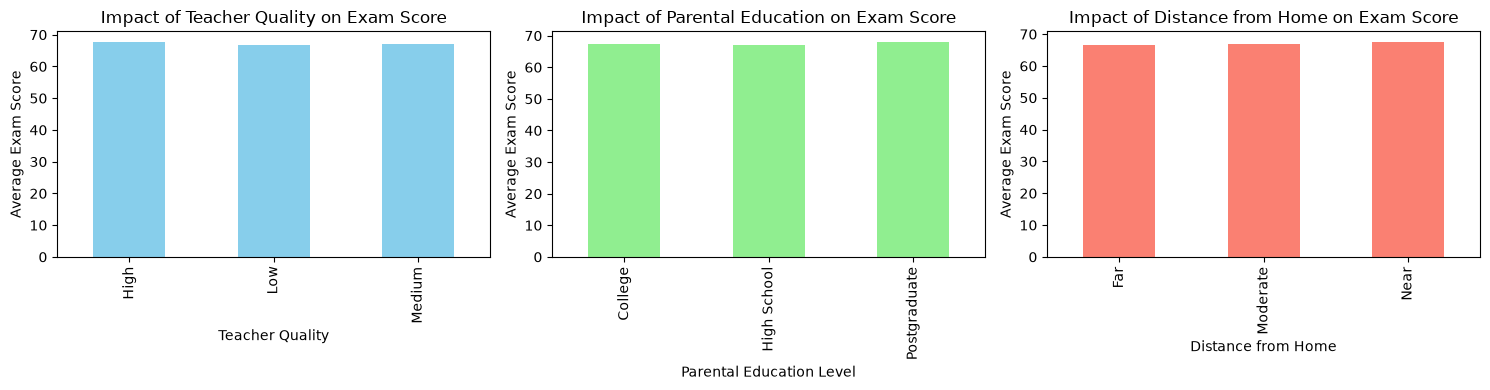

In [53]:
# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Teacher Quality
data.groupby('Teacher_Quality')['Exam_Score'].mean().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Impact of Teacher Quality on Exam Score')
axes[0].set_ylabel('Average Exam Score')
axes[0].set_xlabel('Teacher Quality')

# Parental Education
data.groupby('Parental_Education_Level')['Exam_Score'].mean().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Impact of Parental Education on Exam Score')
axes[1].set_ylabel('Average Exam Score')
axes[1].set_xlabel('Parental Education Level')

# Distance from Home
data.groupby('Distance_from_Home')['Exam_Score'].mean().plot(kind='bar', ax=axes[2], color='salmon')
axes[2].set_title('Impact of Distance from Home on Exam Score')
axes[2].set_ylabel('Average Exam Score')
axes[2].set_xlabel('Distance from Home')

plt.tight_layout()
plt.show()

### Who is scoring more Male or Female Students ?


<Axes: xlabel='Gender'>

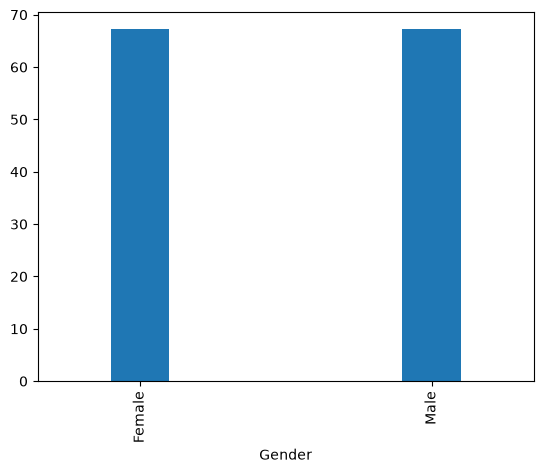

In [54]:
data.groupby('Gender')['Exam_Score'].mean().plot(kind='bar', width=(0.2))

### Checking if attendance and hours study affecting marks

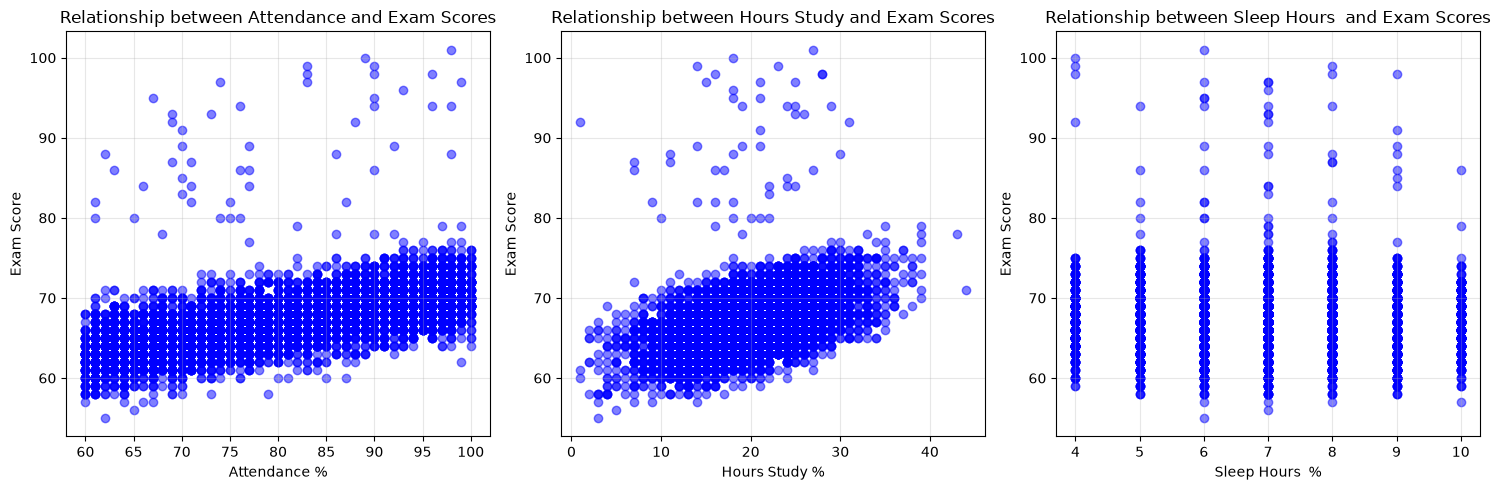

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(data['Attendance'], data['Exam_Score'], alpha=0.5, color='blue')
axes[0].set_xlabel('Attendance %')
axes[0].set_ylabel('Exam Score')
axes[0].set_title('Relationship between Attendance and Exam Scores')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(data['Hours_Studied'], data['Exam_Score'], alpha=0.5, color='blue')
axes[1].set_xlabel('Hours Study %')
axes[1].set_ylabel('Exam Score')
axes[1].set_title('Relationship between Hours Study and Exam Scores')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(data['Sleep_Hours'], data['Exam_Score'], alpha=0.5, color='blue')
axes[2].set_xlabel('Sleep Hours  %')
axes[2].set_ylabel('Exam Score')
axes[2].set_title('Relationship between Sleep Hours  and Exam Scores')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Checking the outliers 

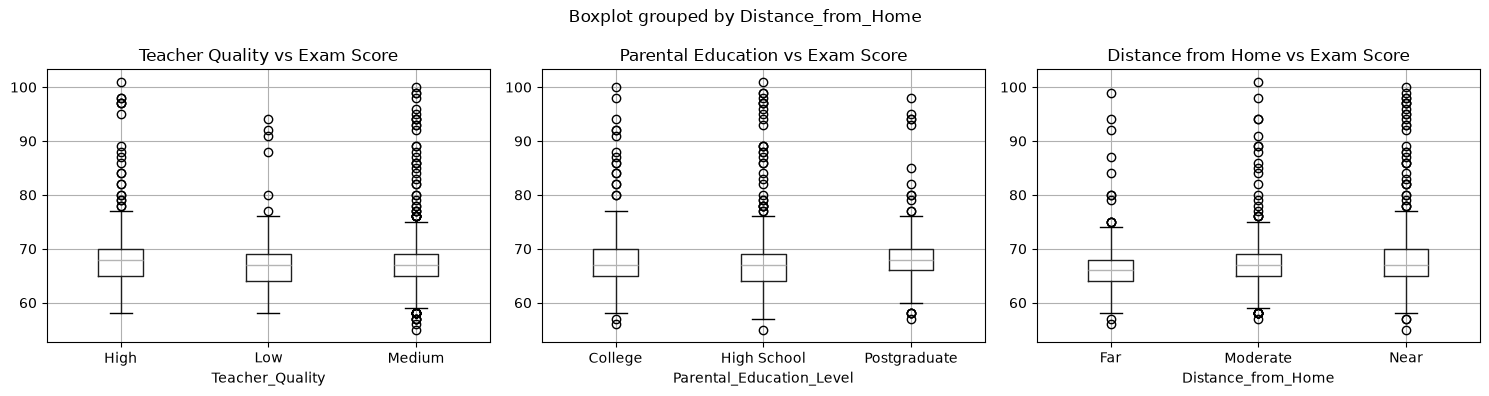

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

data.boxplot(column='Exam_Score', by='Teacher_Quality', ax=axes[0])
axes[0].set_title('Teacher Quality vs Exam Score')

data.boxplot(column='Exam_Score', by='Parental_Education_Level', ax=axes[1])
axes[1].set_title('Parental Education vs Exam Score')

data.boxplot(column='Exam_Score', by='Distance_from_Home', ax=axes[2])
axes[2].set_title('Distance from Home vs Exam Score')

plt.tight_layout()
plt.show()

<Axes: >

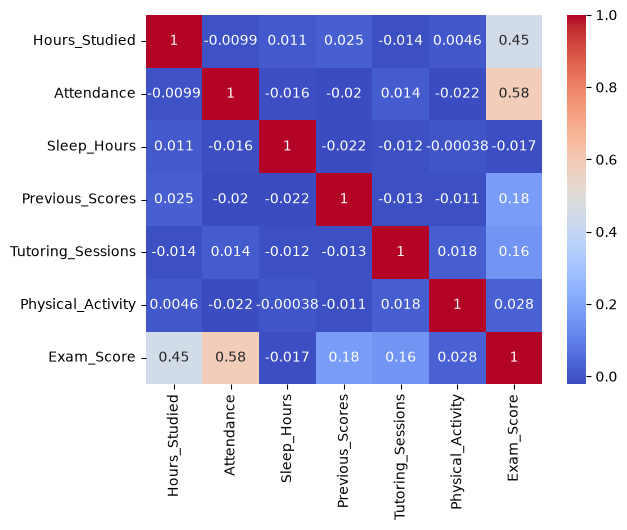

In [57]:

sns.heatmap(data.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')

### saving the file 

In [58]:

data.to_csv(output_data_path, index=False)


### The Findings 

  The analysis indicates that student performance is highly dependent on student-controlled behaviors. Attendance ($r = 0.58$) and Hours Studied ($r = 0.45$) are the strongest positive predictors of high Exam Scores.

Interestingly, external and background factors showed absolutely no impact on student outcomes in this dataset. Average scores remained static regardless of Teacher Quality, Parental Education, or Distance from Home.



Factors like Sleep Hours and Physical Activity showed near-zero correlation with exam performance.

Data is sysnthetically generated , example - boys and girls equally marks and sleep is not affecting marks where in real life it should be 